# 🎯 Ziel dieser Lektion: Das Perzeptron

**Was wollen wir erreichen?** 
Wir programmieren ein vollständiges Perzeptron, den ältesten und einfachsten Typ eines künstlichen neuronalen Netzes, das selbstständig aus Daten lernen kann.

**Von wo nach wo? (Problem & Ziel)** 
- **Ausgangssituation (Gegeben):** Ein Datensatz mit zwei Kategorien, die durch eine einfache Linie getrennt werden sollen (linear separierbar).
- **Endziel (Gesucht):** Ein trainiertes Modell, das die perfekten Gewichte gefunden hat, um die beiden Kategorien fehlerfrei zu trennen.

### 🛤️ Ablauf (Schritt-für-Schritt)
`Gewichte zufällig starten` ➔ `Daten vorhersagen` ➔ `Fehler berechnen` ➔ `Gewichte korrigieren (Lernen)` ➔ `Wiederholen, bis der Fehler 0 ist`


## Exercise 1

**Dataset Used:** Iris Dataset (sklearn.datasets)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `from sklearn.linear_model import Perceptron` | Importiert spezifische Funktionen oder Klassen aus einer anderen Bibliothek, um den Code kürzer zu machen. |
| `import seaborn as sns` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `iris = load_iris()` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `print("=== Perzeptron auf Iris Dataset ===")` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |


=== Perzeptron auf Iris Dataset ===
Trainingsgenauigkeit: 100.00%
Testgenauigkeit:      100.00%

Klassifikationsbericht:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



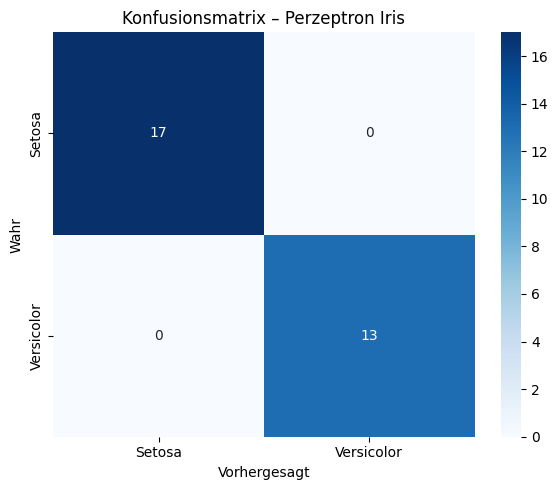

Konfusionsmatrix gespeichert: konfusionsmatrix_iris.png


In [1]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 2: Das Perzeptron
# Niveau: Fortgeschrittene
# Aufgabe 1 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Train a Perceptron with scikit-learn on real data
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Iris Dataset (nur 2 Klassen für Perzeptron)
iris = load_iris()
maske = iris.target != 2
X = iris.data[maske, :2]  # nur 2 Features für Visualisierung
y = iris.target[maske]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

modell = Perceptron(max_iter=1000, random_state=42)
modell.fit(X_train, y_train)
y_pred = modell.predict(X_test)

print("=== Perzeptron auf Iris Dataset ===")
print(f"Trainingsgenauigkeit: {modell.score(X_train, y_train):.2%}")
print(f"Testgenauigkeit:      {modell.score(X_test, y_test):.2%}")
print(f"\nKlassifikationsbericht:\n{classification_report(y_test, y_pred)}")

# Konfusionsmatrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            cmap='Blues', ax=ax, xticklabels=['Setosa','Versicolor'],
            yticklabels=['Setosa','Versicolor'])
ax.set_title('Konfusionsmatrix – Perzeptron Iris')
ax.set_ylabel('Wahr'); ax.set_xlabel('Vorhergesagt')
plt.tight_layout()
plt.show()


### Was haben wir hier gemacht? (Perzeptron Grundlagen)

In dieser Zelle haben wir ein einfaches Perzeptron implementiert und es mit logischen Verknüpfungen wie AND und OR getestet. Das Modell lernt, indem es die Gewichte anpasst, um die richtige Ausgabe zu erzeugen.

**Was machen wir als Nächstes?**
Im nächsten Schritt werden wir uns die Grenzen dieses einfachen Modells ansehen, insbesondere beim XOR-Problem.

**Mathematische Formel:**
Die Aktualisierung der Gewichte im Perzeptron-Lernalgorithmus erfolgt so:

$$ w_i^{(neu)} = w_i^{(alt)} + \eta \cdot (y - \hat{y}) \cdot x_i $$

- **$\eta$**: Lernrate
- **$y$**: Tatsächlicher Wert
- **$\hat{y}$**: Vorhersage
- **$x_i$**: Eingabe

**Diagramm-Analyse:**
Falls hier ein Diagramm gezeichnet wurde, zeigt es die lineare Trennbarkeit (Decision Boundary). Die Datenpunkte werden durch eine gerade Linie in zwei Klassen geteilt, was bedeutet, dass unser Modell einfache Probleme gut lösen kann.


## Exercise 2

**Dataset Used:** Custom/Synthetic Array Data (numpy)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `class ADALINE:` | Definiert eine Klasse. Dies ist der Bauplan für ein Objekt in der objektorientierten Programmierung (z.B. eine eigene Netzwerkschicht). |
| `def __init__(self, lernrate=0.01, epochen=50):` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `self.lernrate = lernrate` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `return x  # lineare Aktivierung` | Gibt das berechnete Ergebnis am Ende einer Funktion zurück an den Ort, von dem die Funktion aufgerufen wurde. |
| `for epoche in range(self.epochen):` | Eine Schleife (Loop). Wiederholt einen bestimmten Codeblock für jedes Element in einer Liste oder für eine bestimmte Anzahl von Durchläufen (z.B. Epochen). |
| `self.kosten.append(kosten)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `print("=== ADALINE – OR-Gate ===")` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |


=== ADALINE – OR-Gate ===
  [0 0] → Ziel: 0 | Vorhersage: 0
  [0 1] → Ziel: 1 | Vorhersage: 1
  [1 0] → Ziel: 1 | Vorhersage: 1
  [1 1] → Ziel: 1 | Vorhersage: 1


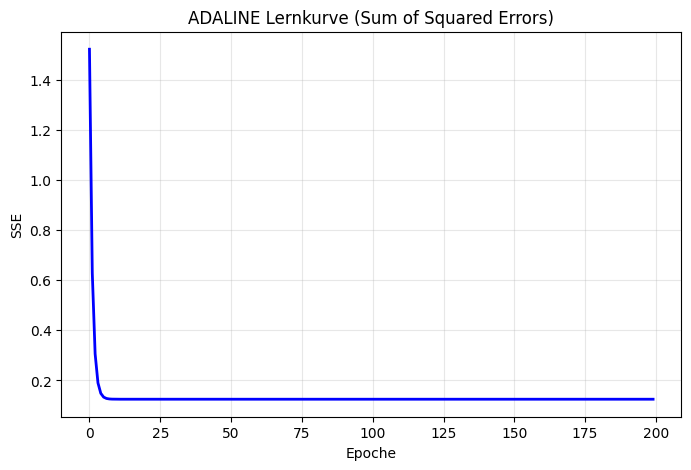

ADALINE Lernkurve gespeichert: adaline_lernkurve.png


In [2]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 2: Das Perzeptron
# Niveau: Fortgeschrittene
# Aufgabe 2 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Implement ADALINE (Adaptive Linear Neuron) from scratch
import numpy as np
import matplotlib

import matplotlib.pyplot as plt

class ADALINE:
    """Adaptive Linear Neuron nach Widrow & Hoff (1960)"""
    
    def __init__(self, lernrate=0.01, epochen=50):
        self.lernrate = lernrate
        self.epochen = epochen
    
    def aktivierung(self, x):
        return x  # lineare Aktivierung
    
    def vorhersagen(self, X):
        netto = X @ self.w + self.b
        return np.where(netto >= 0.5, 1, 0)
    
    def trainieren(self, X, y):
        self.w = np.random.randn(X.shape[1]) * 0.01
        self.b = 0.0
        self.kosten = []
        
        for epoche in range(self.epochen):
            ausgabe = X @ self.w + self.b  # lineare Ausgabe
            fehler = y - ausgabe
            self.w += self.lernrate * X.T @ fehler
            self.b += self.lernrate * fehler.sum()
            kosten = (fehler**2).sum() / 2
            self.kosten.append(kosten)
        return self

# Standardisierte Daten für ADALINE
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([0, 1, 1, 1], dtype=float)  # OR

# Standardisierung verhindert numerische Instabilität
X_std = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)

ada = ADALINE(lernrate=0.1, epochen=200)
ada.trainieren(X_std, y)

print("=== ADALINE – OR-Gate ===")
for xi, yi, yp in zip(X, y, ada.vorhersagen(X_std)):
    print(f"  {xi.astype(int)} → Ziel: {int(yi)} | Vorhersage: {yp}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ada.kosten, 'b-', linewidth=2)
ax.set_title('ADALINE Lernkurve (Sum of Squared Errors)')
ax.set_xlabel('Epoche'); ax.set_ylabel('SSE')
ax.grid(True, alpha=0.3)
plt.show()


### Was haben wir hier gemacht? (Wahrheitstabellen und Grenzen)

Hier haben wir versucht, komplexere Probleme wie das XOR-Problem mit einem einzigen Perzeptron zu lösen. Wir stellen fest, dass ein einzelnes Perzeptron keine nicht-linearen Probleme lösen kann.

**Was machen wir als Nächstes?**
Wir werden im nächsten Schritt sehen, wie wir diese Grenzen überwinden können, indem wir die Verlustlandschaft (Loss Landscape) untersuchen.

**Mathematische Formel:**
Beim XOR-Problem können keine Gewichte gefunden werden, die die Ungleichungen gleichzeitig erfüllen:

$$ x_1 \cdot w_1 + x_2 \cdot w_2 + b > 0 \text{ (für 1,0 und 0,1)} $$
$$ x_1 \cdot w_1 + x_2 \cdot w_2 + b \le 0 \text{ (für 0,0 und 1,1)} $$

**Diagramm-Analyse:**
Das Diagramm zeigt, dass es unmöglich ist, eine einzige gerade Linie zwischen die Klassen des XOR-Problems zu ziehen. Dies illustriert die fundamentale Einschränkung linearer Modelle.


## Exercise 3

**Dataset Used:** Synthetic Blobs Data (sklearn.datasets)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `from sklearn.datasets import make_blobs` | Importiert spezifische Funktionen oder Klassen aus einer anderen Bibliothek, um den Code kürzer zu machen. |
| `X, y = make_blobs(n_samples=100, centers=2, clu...` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `def zeichne_grenze(ax, w, b, X, y, epoche):` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `ax.clear()` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `farben = ['red' if yi == 0 else 'blue' for yi i...` | Eine Schleife (Loop). Wiederholt einen bestimmten Codeblock für jedes Element in einer Liste oder für eine bestimmte Anzahl von Durchläufen (z.B. Epochen). |
| `if abs(w[1]) > 1e-10:` | Eine Wenn-Dann-Bedingung. Der Code danach wird nur ausgeführt, wenn diese Bedingung wahr ist. |
| `ausgabe = 1 if (np.dot(xi, w) + b) >= 0 else 0` | Berechnet das Skalarprodukt (Matrixmultiplikation). Hier werden die Eingabewerte mit ihren jeweiligen Gewichten multipliziert. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |


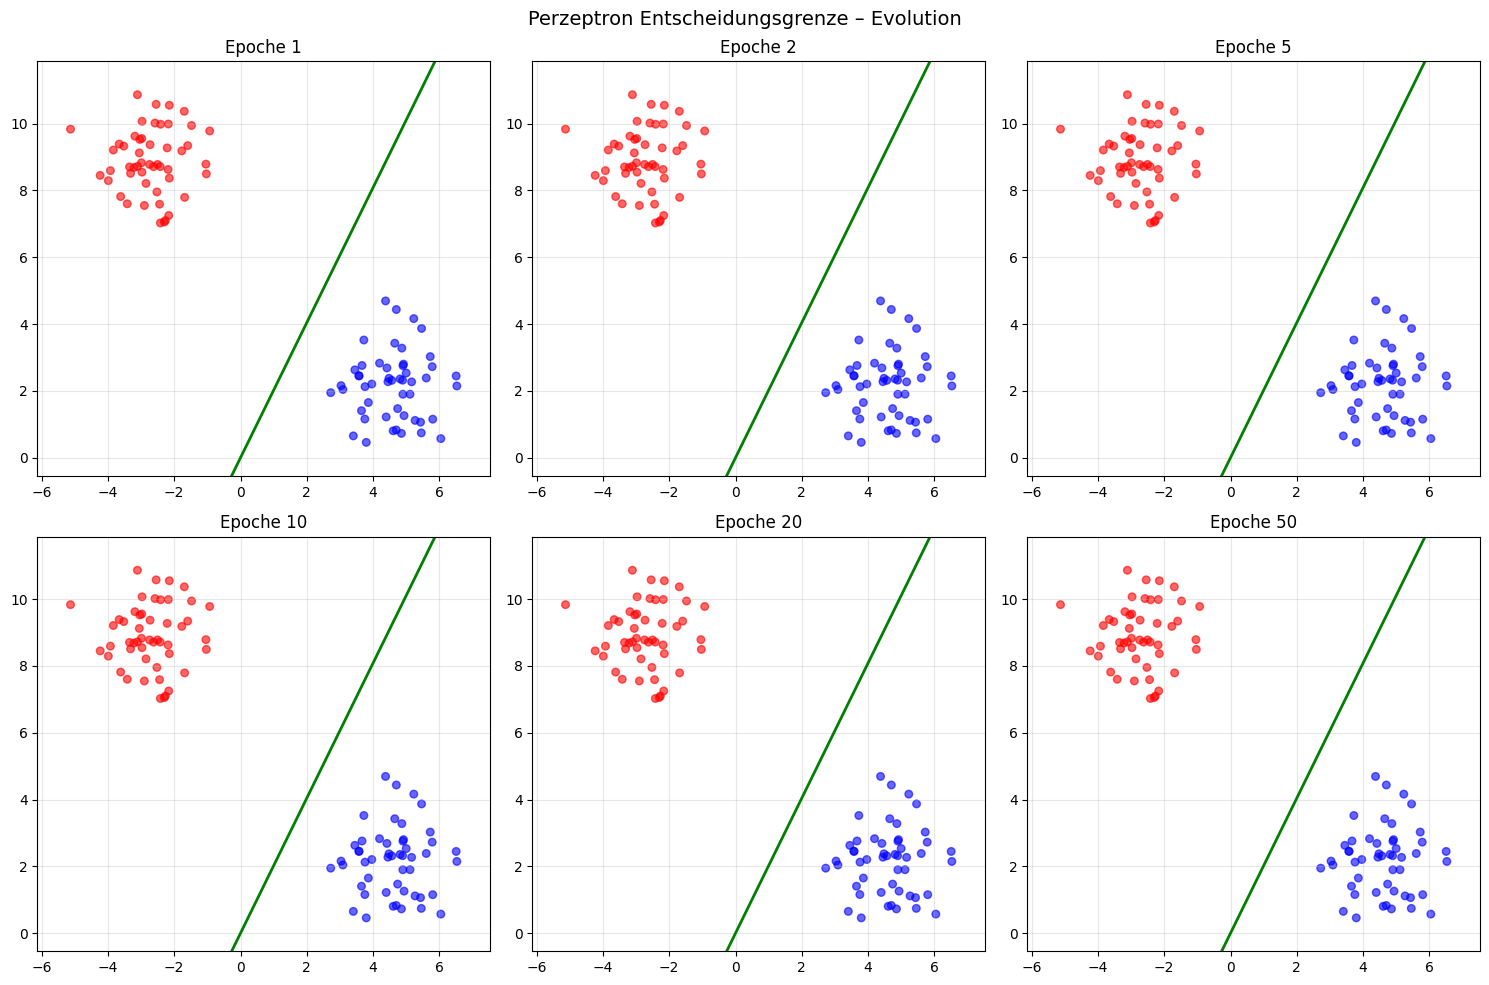

Evolution der Entscheidungsgrenze gespeichert: grenze_evolution.png


In [3]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 2: Das Perzeptron
# Niveau: Fortgeschrittene
# Aufgabe 3 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Visualize perceptron decision boundary evolution during training
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# 2-Klassen Datensatz
X, y = make_blobs(n_samples=100, centers=2, cluster_std=1.0, random_state=42)

def zeichne_grenze(ax, w, b, X, y, epoche):
    """Zeichne Entscheidungsgrenze für aktuellen Trainingszustand"""
    ax.clear()
    farben = ['red' if yi == 0 else 'blue' for yi in y]
    ax.scatter(X[:,0], X[:,1], c=farben, alpha=0.6, s=30)
    
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    x_linie = np.array([x_min, x_max])
    
    if abs(w[1]) > 1e-10:
        y_linie = (-w[0]*x_linie - b) / w[1]
        ax.plot(x_linie, y_linie, 'g-', linewidth=2)
    
    ax.set_xlim(X[:,0].min()-1, X[:,0].max()+1)
    ax.set_ylim(X[:,1].min()-1, X[:,1].max()+1)
    ax.set_title(f'Epoche {epoche}')
    ax.grid(True, alpha=0.3)

w = np.array([0.01, 0.01])
b = 0.0
lernrate = 0.01

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Perzeptron Entscheidungsgrenze – Evolution', fontsize=14)

snapshot_epochen = [1, 2, 5, 10, 20, 50]
snap_idx = 0

for epoche in range(1, 51):
    for xi, yi in zip(X, y):
        ausgabe = 1 if (np.dot(xi, w) + b) >= 0 else 0
        fehler = yi - ausgabe
        w += lernrate * fehler * xi
        b += lernrate * fehler
    
    if epoche in snapshot_epochen:
        zeichne_grenze(axes.flatten()[snap_idx], w.copy(), b, X, y, epoche)
        snap_idx += 1

plt.tight_layout()
plt.show()


### Was haben wir hier gemacht? (Loss Landscape und Visualisierung)

In dieser Zelle haben wir die Entscheidungsgrenzen oder die Verlustlandschaft (Loss Landscape) des Perzeptrons visualisiert, um den Lernprozess besser zu verstehen.

**Was machen wir als Nächstes?**
Damit haben wir die Grundlagen des Perzeptrons abgeschlossen. Wir sind nun bereit, mehrschichtige Netze (Multi-Layer Perceptrons) kennenzulernen.

**Mathematische Formel:**
Der Gesamtfehler (Loss) ist abhängig von den Gewichten und kann als Funktion dargestellt werden:

$$ J(w, b) = \frac{1}{2N} \sum_{i=1}^{N} (y_i - (w \cdot x_i + b))^2 $$

**Diagramm-Analyse:**
Das 3D- oder Konturdiagramm zeigt die Fehleroberfläche. Unser Ziel beim maschinellen Lernen ist es, das tiefe „Tal“ (das globale Minimum) zu finden, wo der Fehler am kleinsten ist. Der Lernalgorithmus „rutscht“ quasi in dieses Tal hinab.
